# analyze data

In [110]:
import polars as pl
import seaborn as sns
sns.set_theme(style="darkgrid")
sns.despine(top=True, right=True, left=True, bottom=True)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

<Figure size 640x480 with 0 Axes>

In [111]:
data = pl.read_csv('data/smartphone_battery_features.csv')
data.head()

Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
str,i64,i64,f64,f64,f64,f64,i64,f64,f64,str,str,i64,f64,f64
"""207dd94c-0430-43aa-b388-489344…",38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,"""Medium""","""Poor""",4,10.0,4.04
"""3f4d1d33-ba89-4814-a168-7b4cc7…",28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,"""Medium""","""Good""",7,10.0,4.23
"""b4adca05-564f-4b70-ab69-e8d66e…",14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,"""Medium""","""Good""",6,10.0,2.21
"""4147e039-31b7-480a-bbc9-03cd0f…",42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,"""Medium""","""Good""",8,10.0,3.13
"""3f9b0fb7-73c2-4ab7-8e30-7b4920…",7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,"""High""","""Good""",5,10.0,4.95


## targets

In [112]:
targets = pl.read_csv('data/smartphone_battery_targets.csv')
targets.head()

Device_ID,current_battery_health_percent,recommended_action
str,f64,str
"""207dd94c-0430-43aa-b388-489344…",32.8,"""Change Phone"""
"""3f4d1d33-ba89-4814-a168-7b4cc7…",50.3,"""Replace Battery"""
"""b4adca05-564f-4b70-ab69-e8d66e…",66.1,"""Replace Battery"""
"""4147e039-31b7-480a-bbc9-03cd0f…",46.8,"""Change Phone"""
"""3f9b0fb7-73c2-4ab7-8e30-7b4920…",67.2,"""Replace Battery"""


#### target distribution

In [113]:
targets['recommended_action'].unique()

recommended_action
str
"""Keep Using"""
"""Replace Battery"""
"""Change Phone"""


In [114]:
targets_distributions = targets.group_by('recommended_action').agg(
    pl.col('current_battery_health_percent').max().alias('max_health_percentage'),
    pl.col('current_battery_health_percent').min().alias('min_health_percentage'),
    pl.col('current_battery_health_percent').mean().round(2).alias('mean_health_percentage'),
    pl.col('current_battery_health_percent').count().alias('count')
    )

targets_distributions

recommended_action,max_health_percentage,min_health_percentage,mean_health_percentage,count
str,f64,f64,f64,u32
"""Replace Battery""",74.9,50.0,62.94,2325
"""Change Phone""",49.9,10.0,38.37,1235
"""Keep Using""",100.0,75.0,82.81,1440


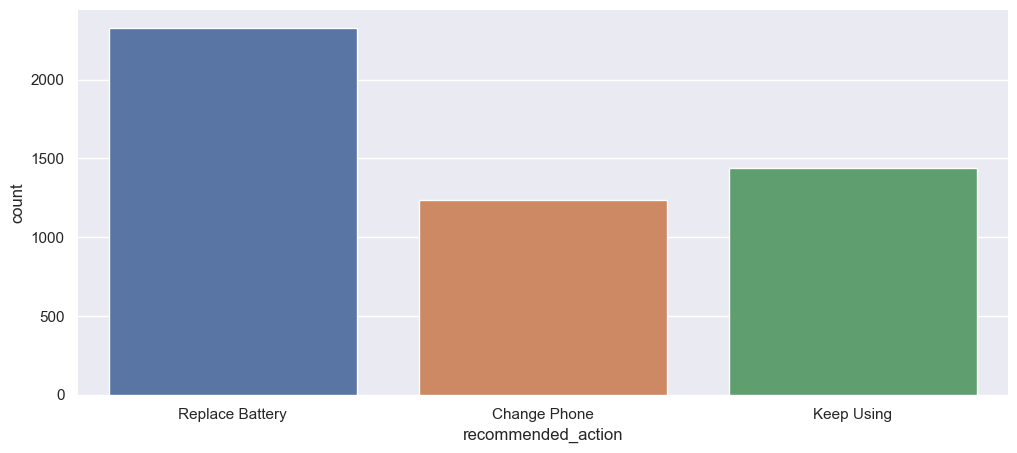

In [115]:
g = sns.barplot(
    x=targets_distributions['recommended_action'], 
    y=targets_distributions['count'], 
    hue=targets_distributions['recommended_action'])
g.figure.set_size_inches(12, 5)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.show()

In [116]:
data = data.join(targets, on='Device_ID', how='left')

In [117]:
data.head()

Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
str,i64,i64,f64,f64,f64,f64,i64,f64,f64,str,str,i64,f64,f64,f64,str
"""207dd94c-0430-43aa-b388-489344…",38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,"""Medium""","""Poor""",4,10.0,4.04,32.8,"""Change Phone"""
"""3f4d1d33-ba89-4814-a168-7b4cc7…",28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,"""Medium""","""Good""",7,10.0,4.23,50.3,"""Replace Battery"""
"""b4adca05-564f-4b70-ab69-e8d66e…",14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,"""Medium""","""Good""",6,10.0,2.21,66.1,"""Replace Battery"""
"""4147e039-31b7-480a-bbc9-03cd0f…",42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,"""Medium""","""Good""",8,10.0,3.13,46.8,"""Change Phone"""
"""3f9b0fb7-73c2-4ab7-8e30-7b4920…",7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,"""High""","""Good""",5,10.0,4.95,67.2,"""Replace Battery"""


### distribution of device age in months

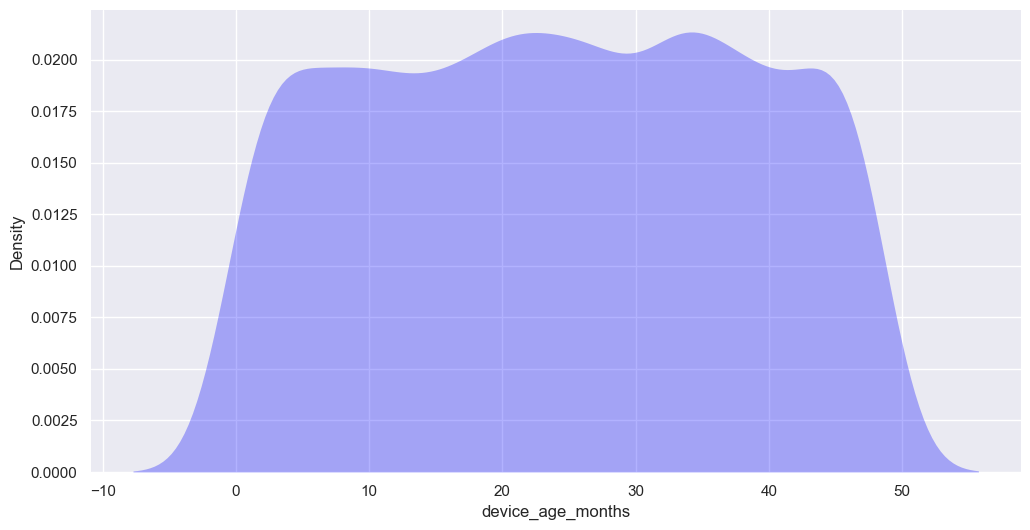

In [118]:
g = sns.kdeplot(
    data=data,
    x = 'device_age_months',
    fill=True,
    linewidth=0,
    common_norm=False,
    alpha=0.3,
    color='blue'
)
g.figure.set_size_inches(12, 6)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.show()

DEVICE AGE MONTHS


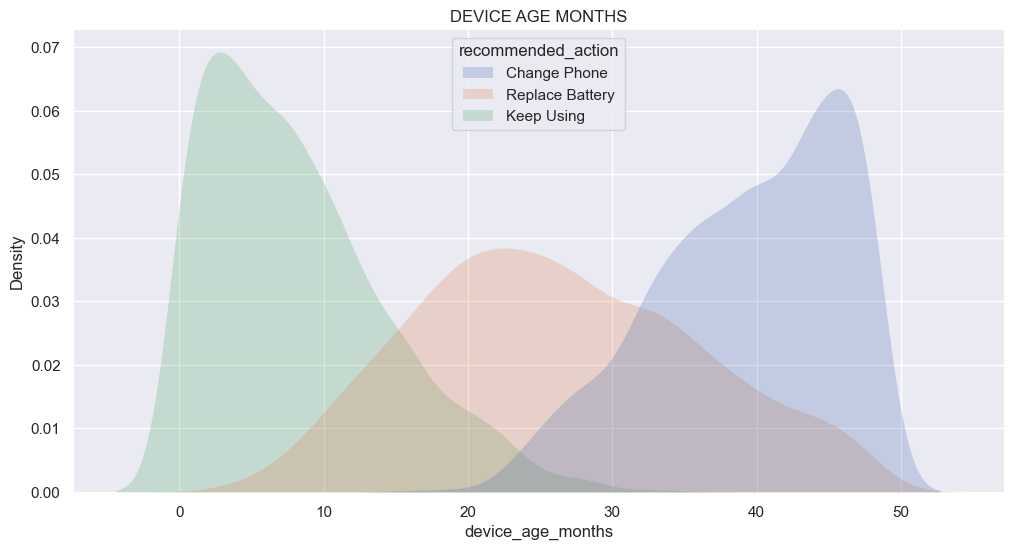

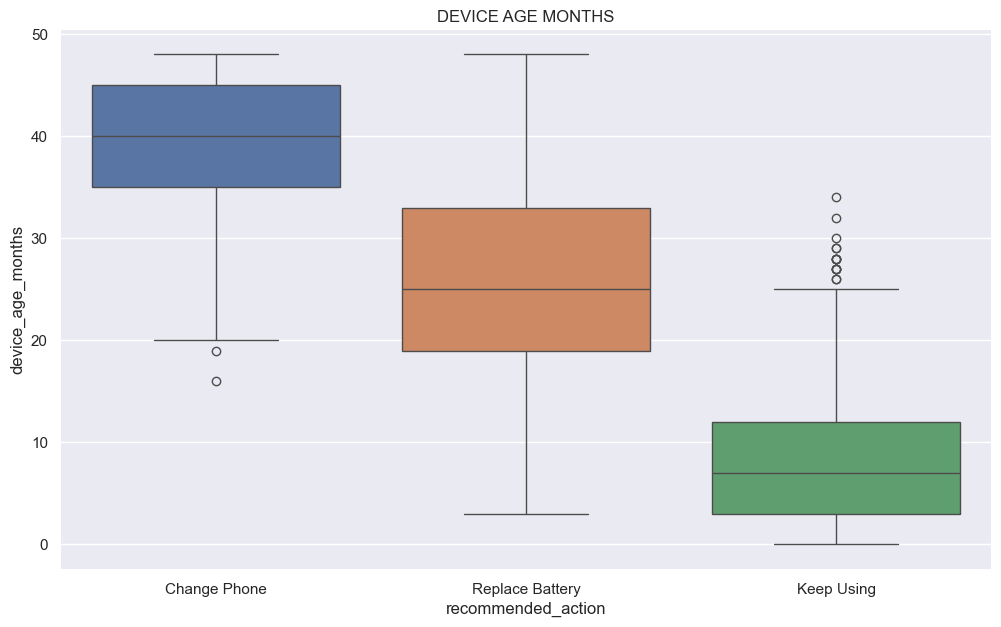

BATTERY CAPACITY MAH


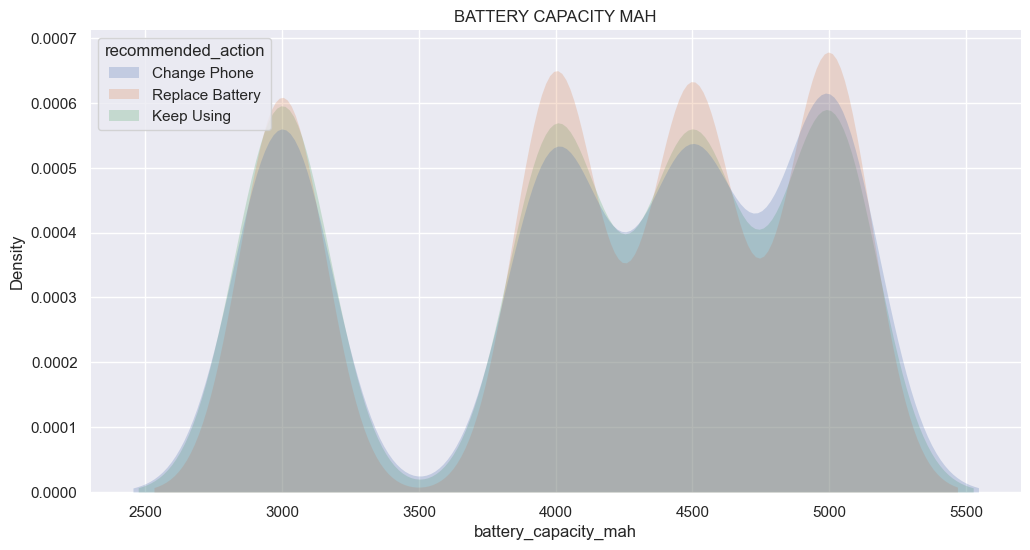

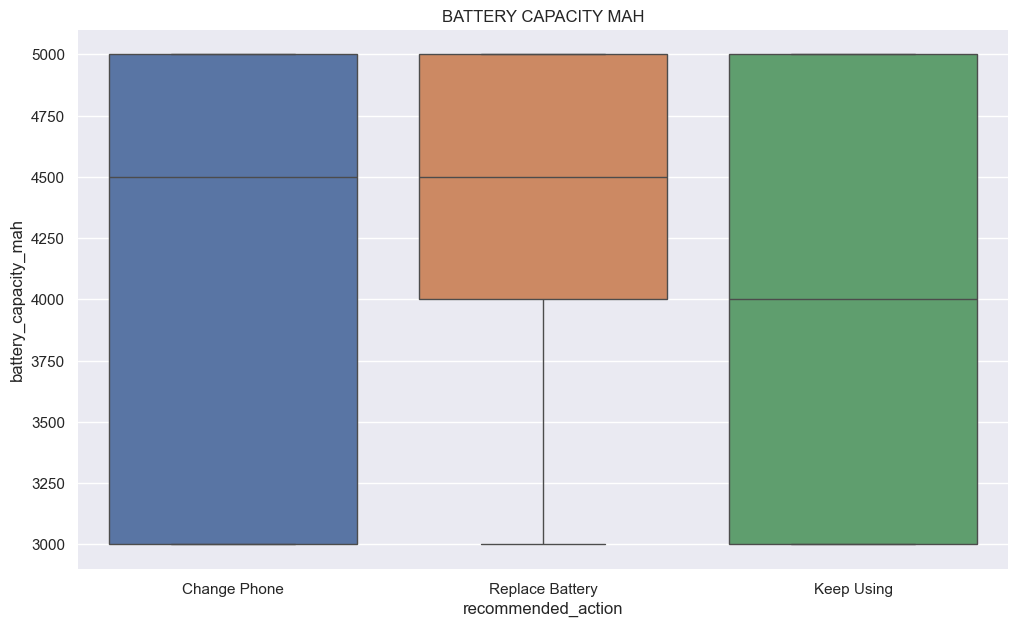

AVG SCREEN ON HOURS PER DAY


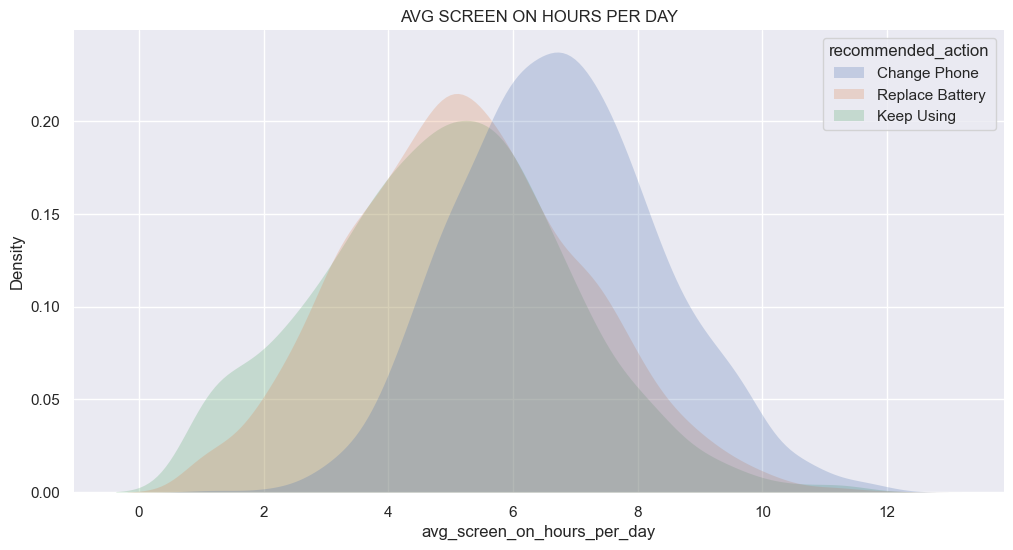

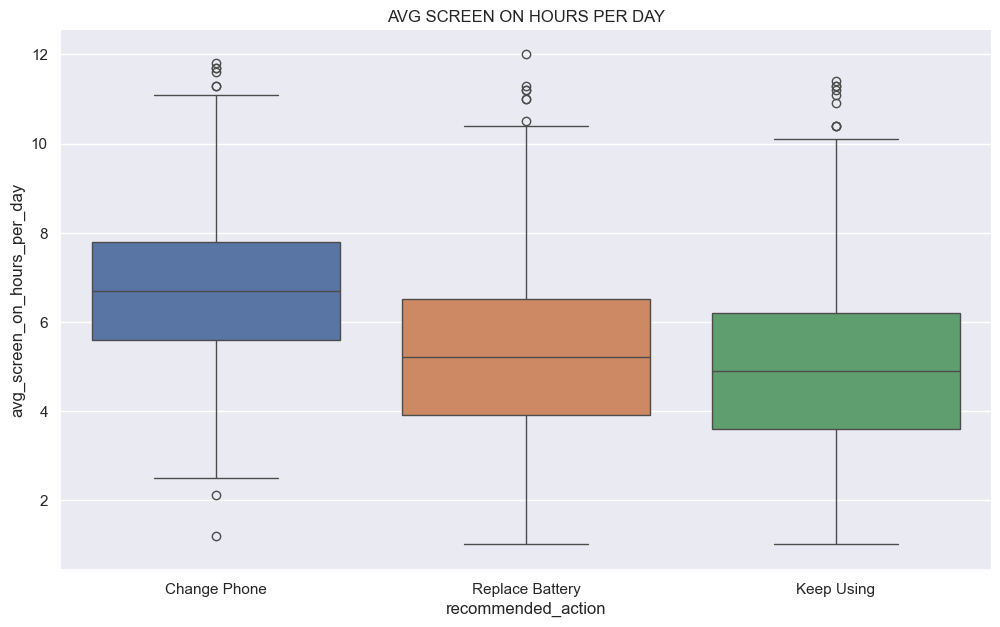

AVG CHARGING CYCLES PER WEEK


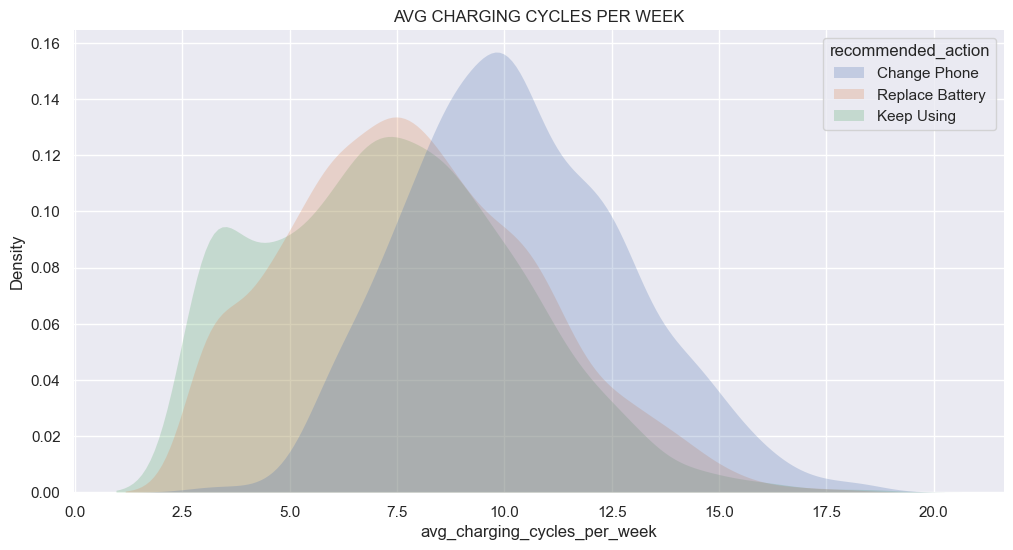

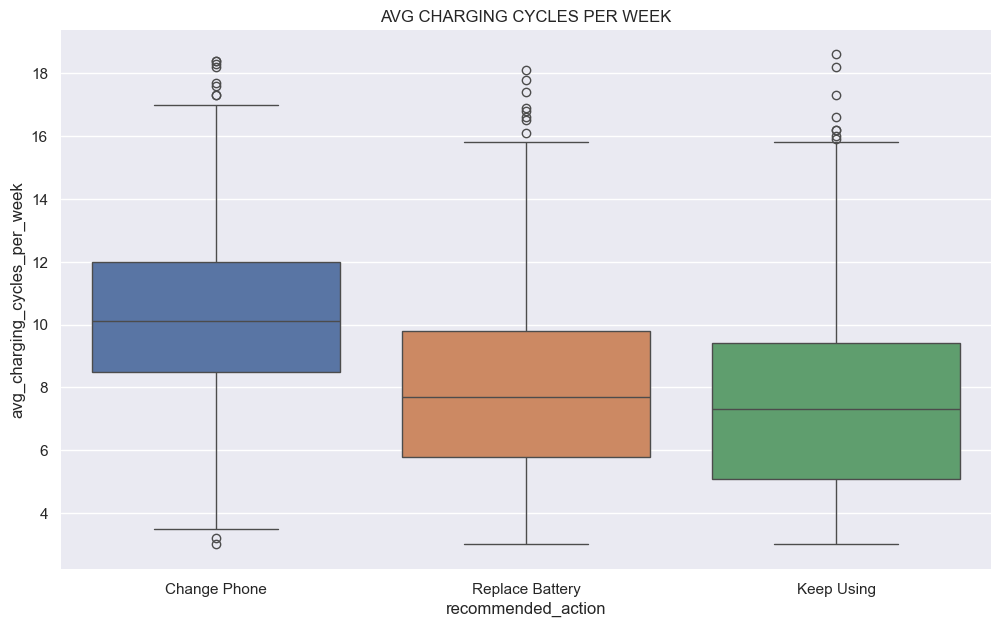

AVG BATTERY TEMP CELSIUS


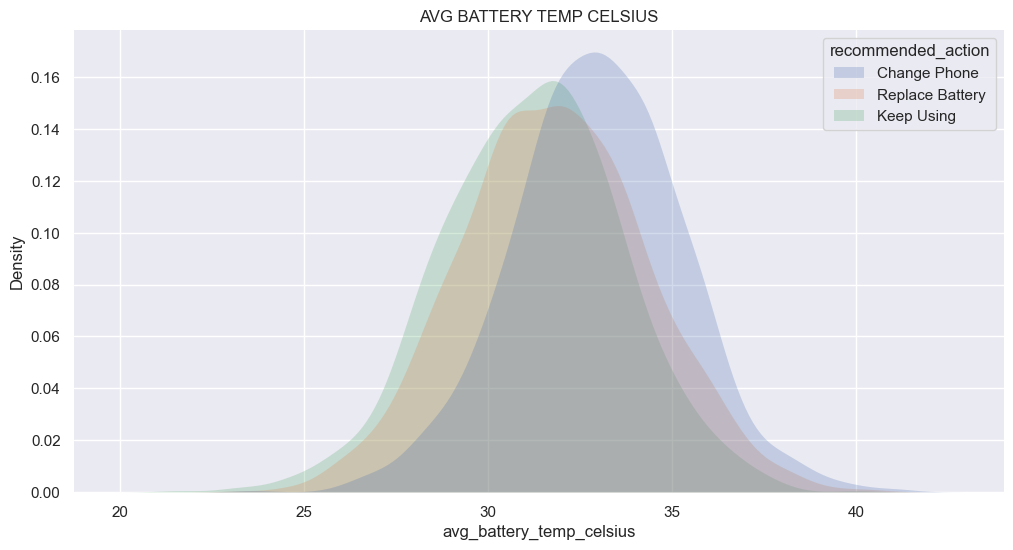

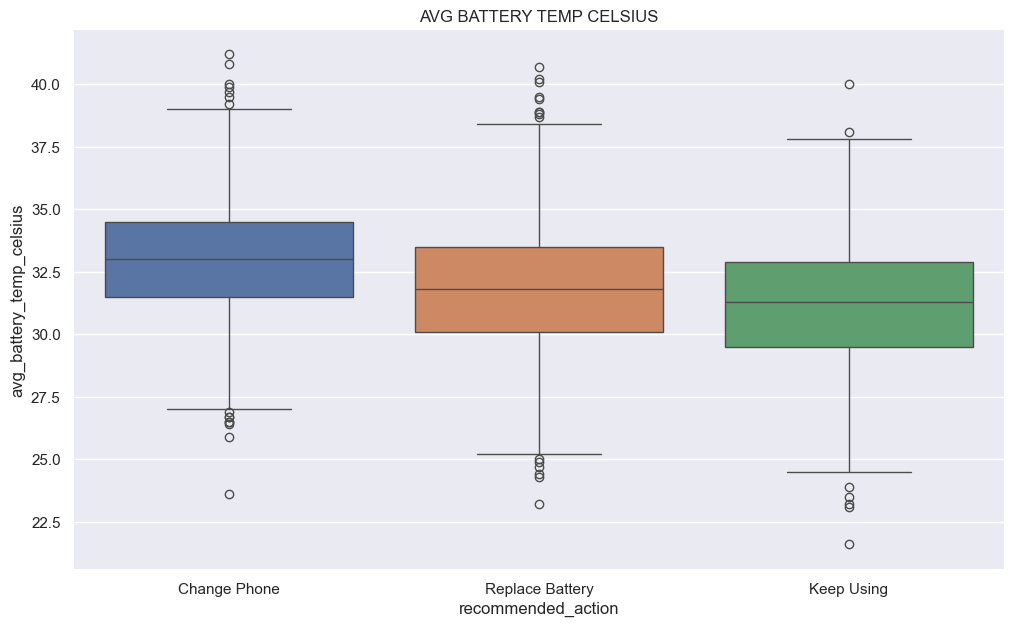

FAST CHARGING USAGE PERCENT


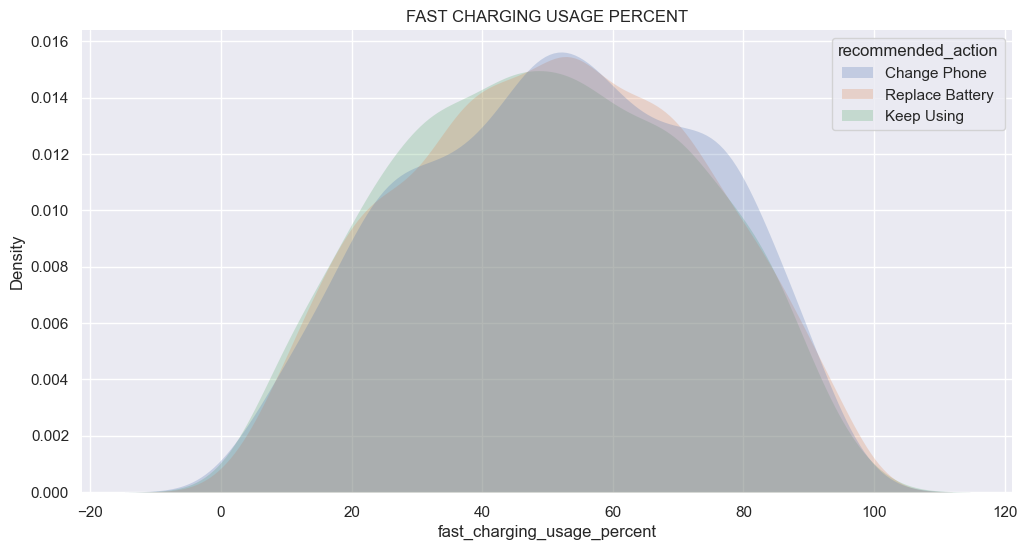

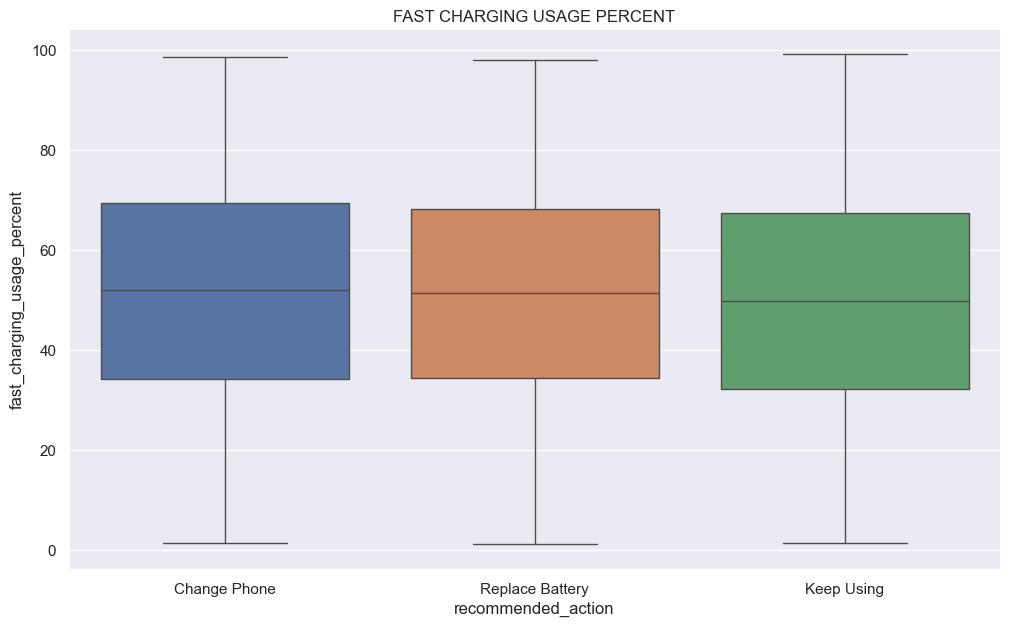

OVERNIGHT CHARGING FREQ PER WEEK


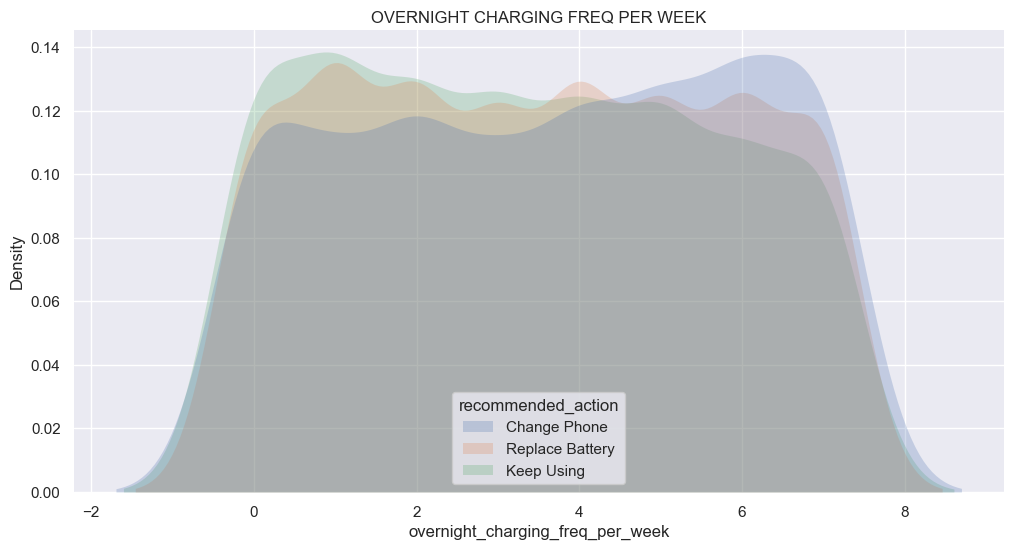

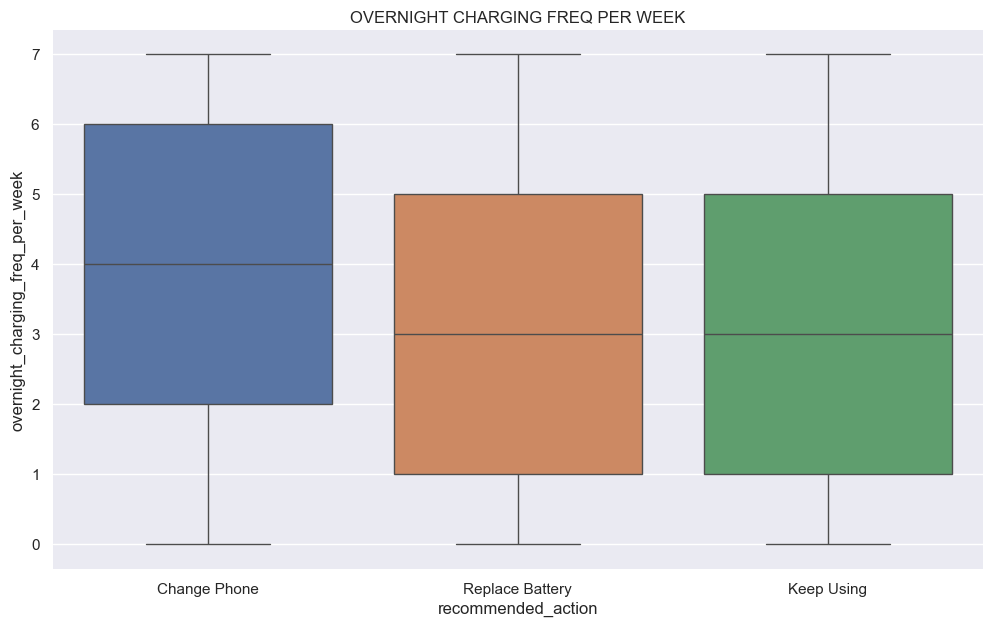

GAMING HOURS PER WEEK


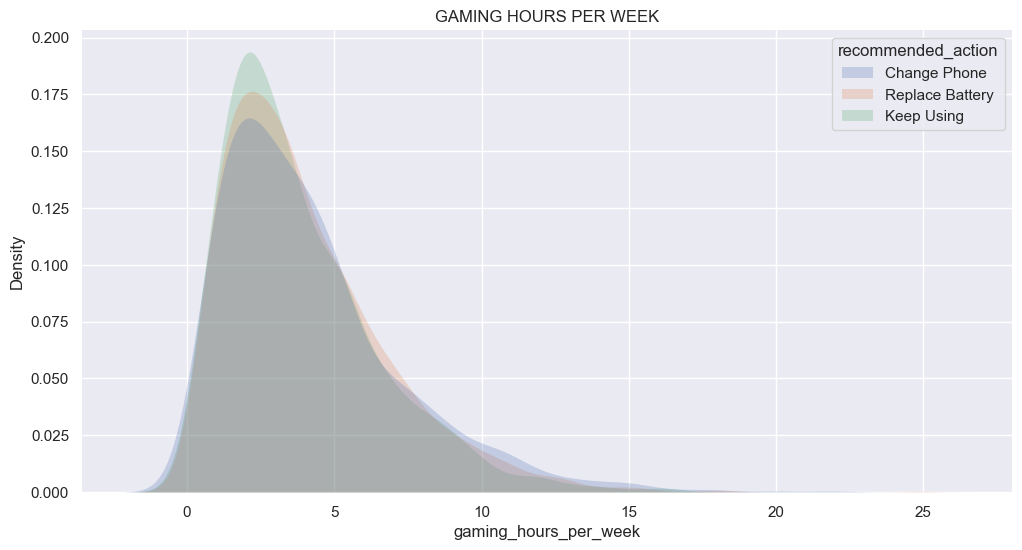

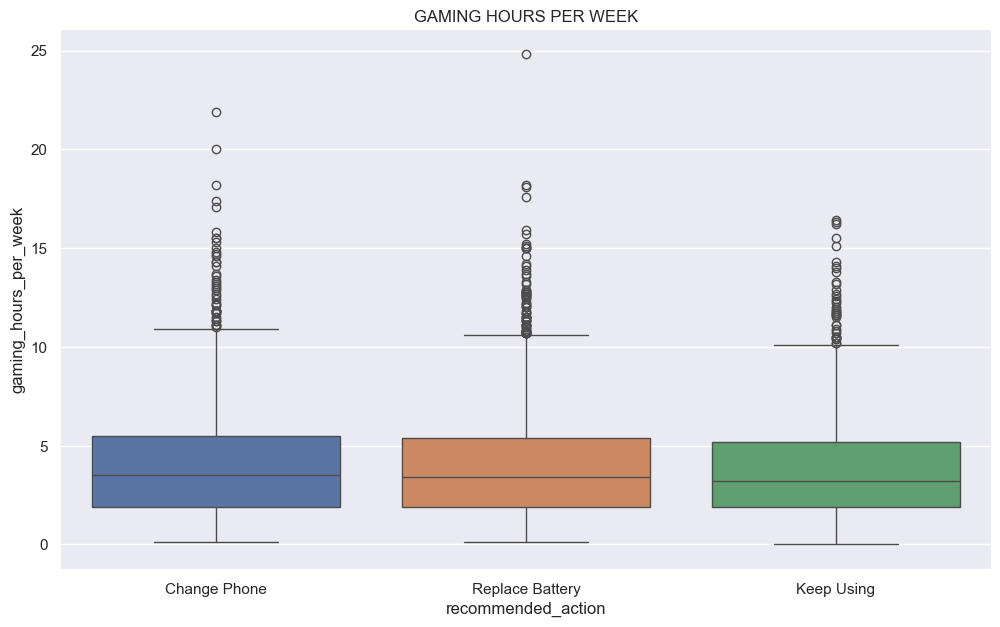

VIDEO STREAMING HOURS PER WEEK


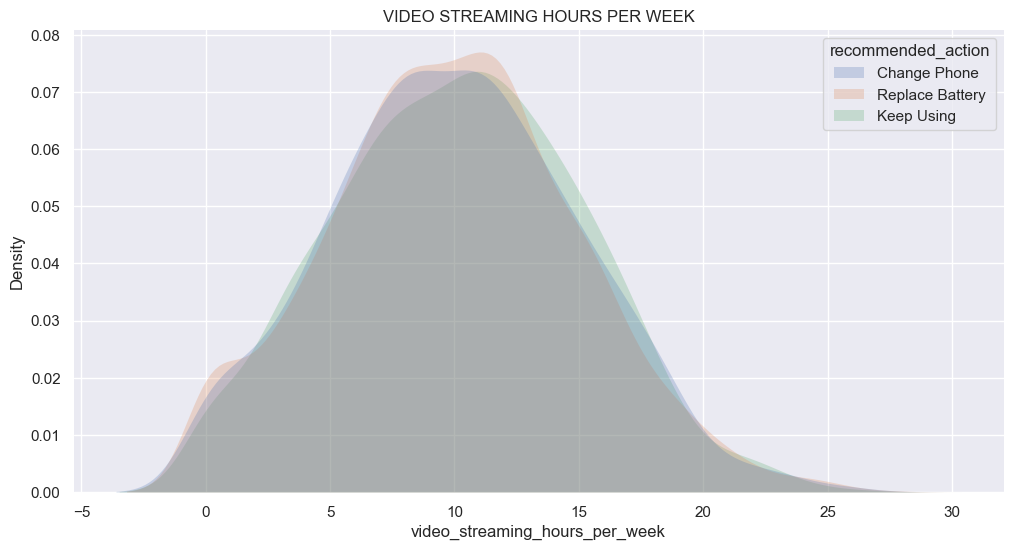

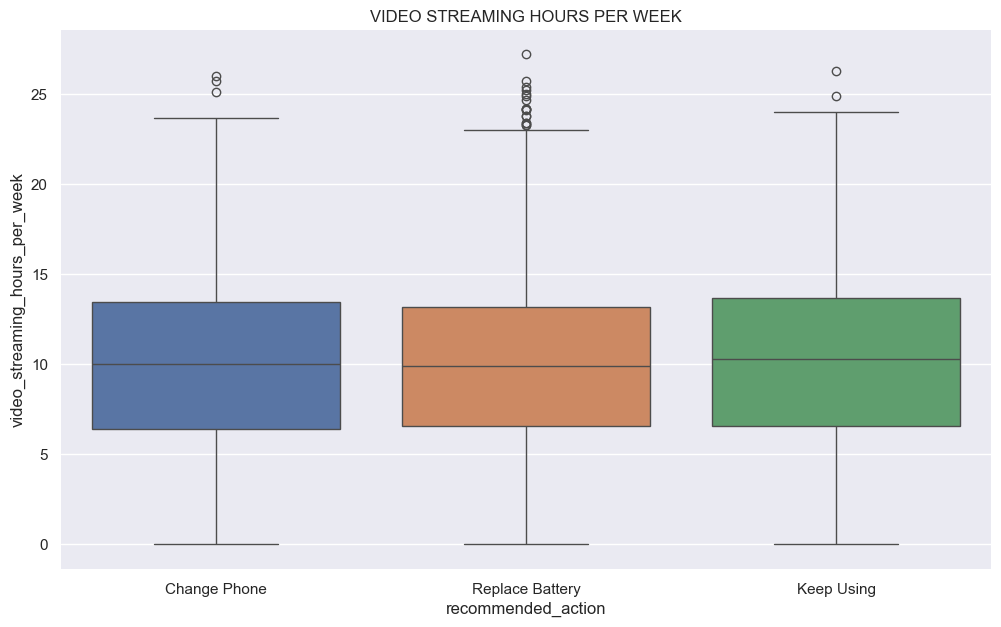

CHARGING HABIT SCORE


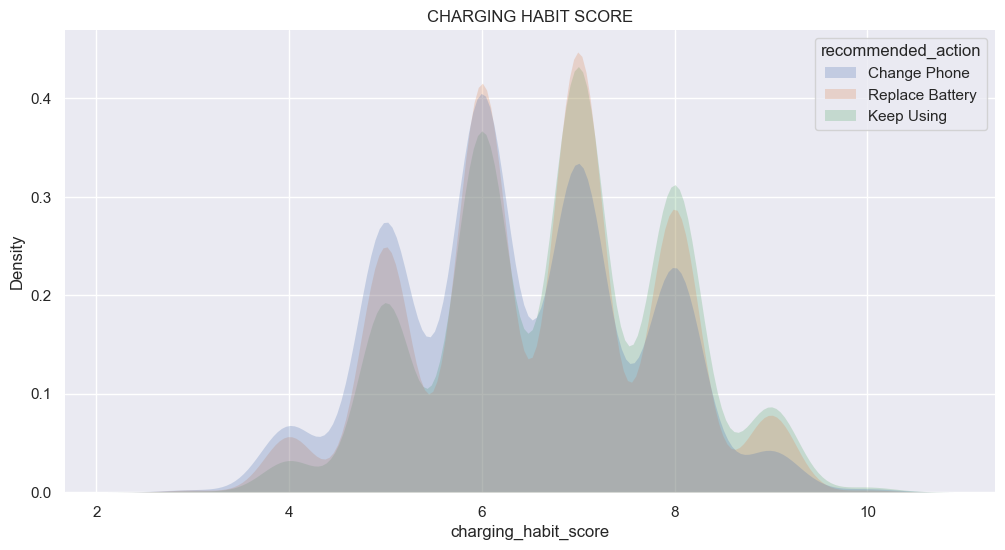

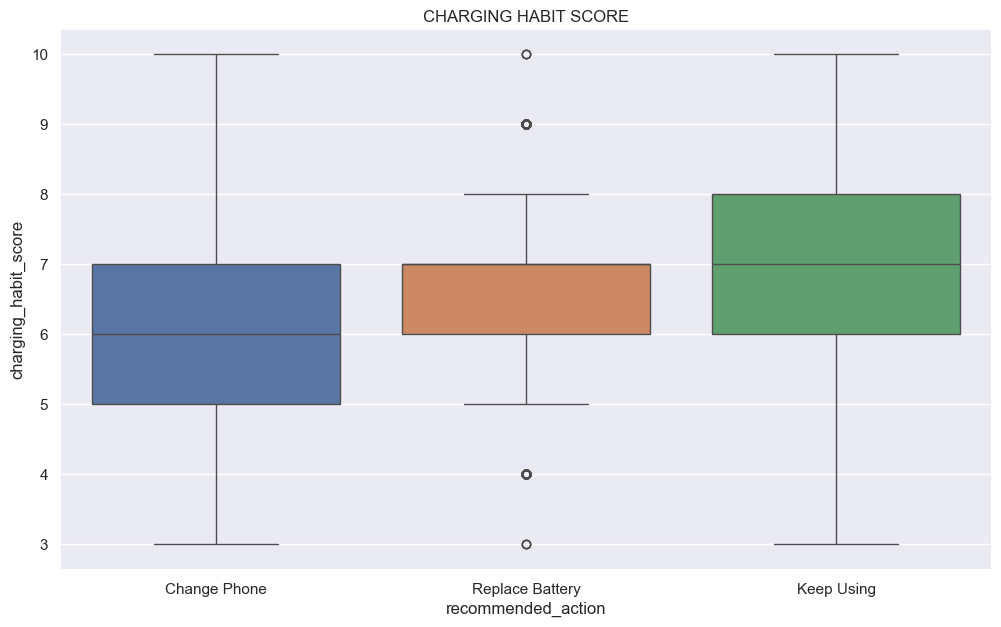

USAGE INTENSITY SCORE


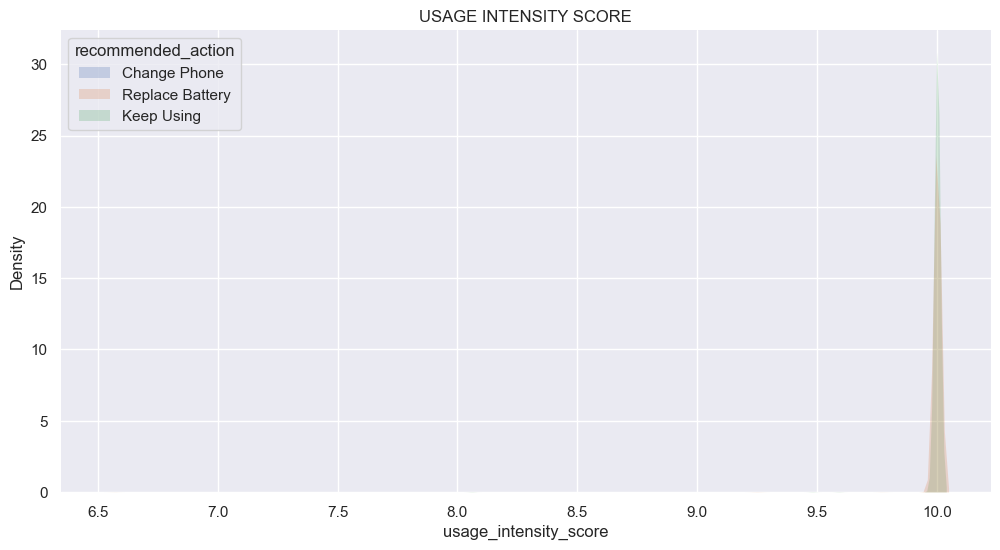

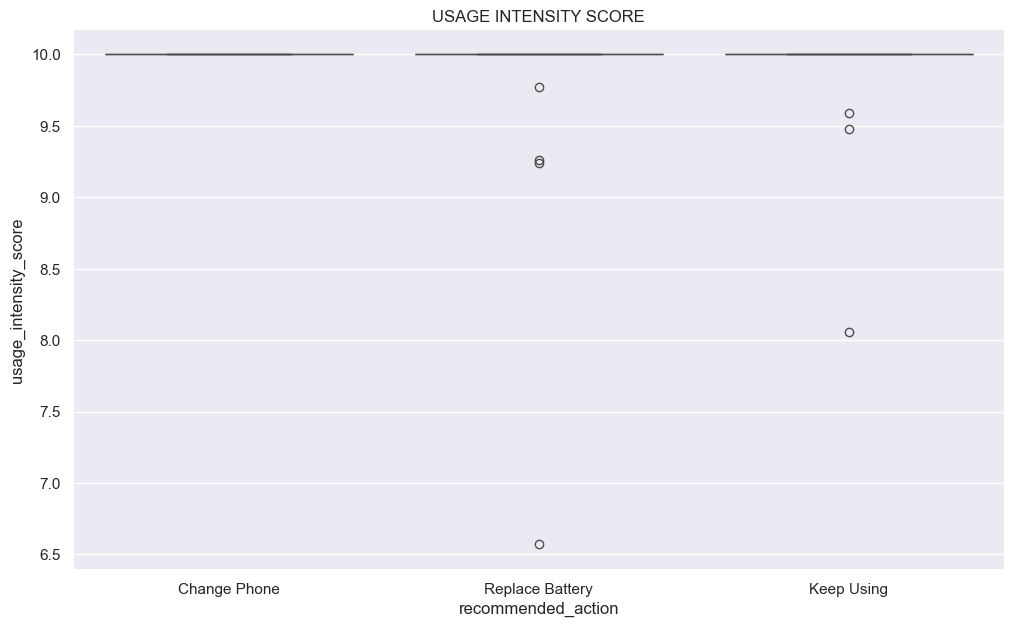

THERMAL STRESS INDEX


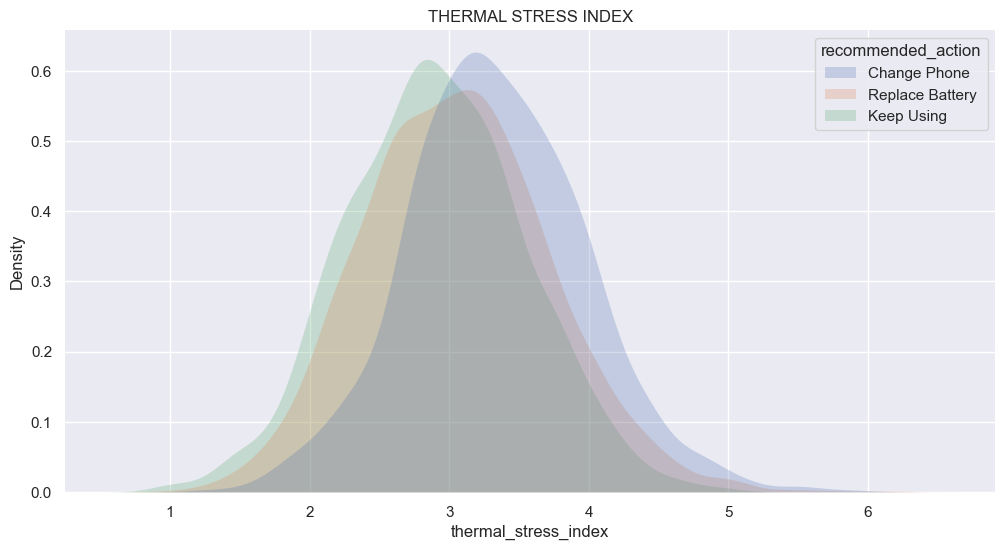

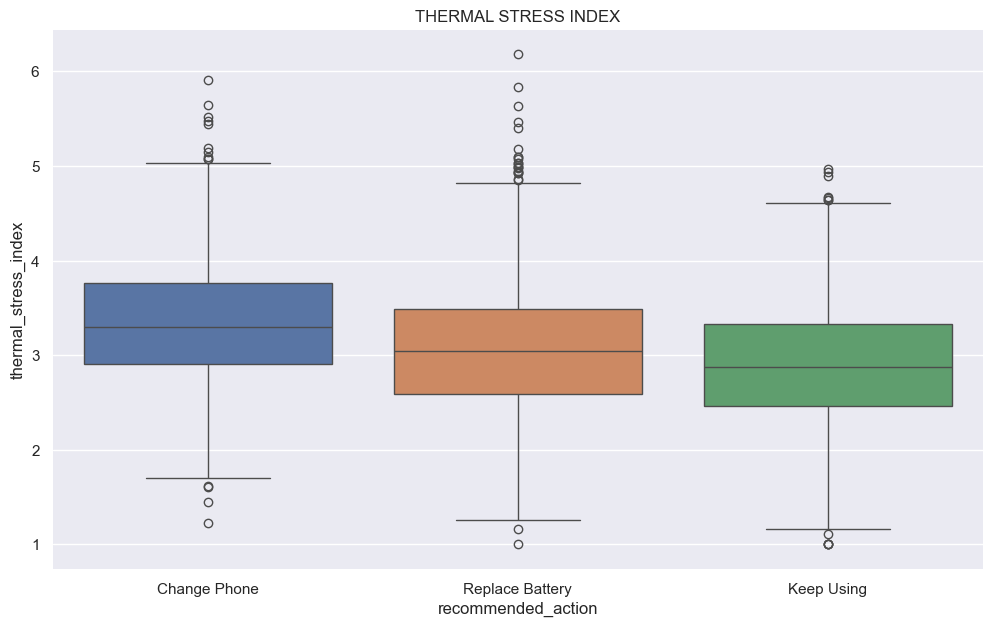

In [119]:
numerical_columns = [
    'device_age_months',
    'battery_capacity_mah',
    'avg_screen_on_hours_per_day',
    'avg_charging_cycles_per_week',
    'avg_battery_temp_celsius',
    'fast_charging_usage_percent',
    'overnight_charging_freq_per_week',
    'gaming_hours_per_week',
    'video_streaming_hours_per_week',
    'charging_habit_score',
    'usage_intensity_score',
    'thermal_stress_index'
]
for  col in numerical_columns:
    title = col.replace('_', ' ').upper()
    print(title)
    g = sns.kdeplot(
        data=data,
        x = col,
        fill=True,
        hue='recommended_action',
        linewidth=0,
        common_norm=False
    )
    g.figure.set_size_inches(12, 6)
    sns.despine(top=True, right=True, left=True, bottom=True)
    plt.title(title)
    plt.show()

    g = sns.boxplot(
        data=data,  
        y=col, 
        x='recommended_action', 
        hue='recommended_action')
    g.figure.set_size_inches(12, 7)
    sns.despine(top=True, right=True, left=True, bottom=True)
    plt.title(title)
    plt.show()